# 99 Final Thesis Figures

Finale Abbildungen aus den freigegebenen Ergebnistabellen.

In [1]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
NAVY = '#17365D'
BLUE = '#3E6F9E'
PALE_BLUE = '#DCE8F2'
ORANGE = '#C65D18'
PALE_ORANGE = '#F5E4D7'
DARK = '#1C2025'
GREY = '#6B7280'
MID_GREY = '#A7AFB7'
LIGHT_GREY = '#E7EAEE'
VERY_LIGHT = '#F6F7F9'
WHITE = '#FFFFFF'
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10.0, 'axes.titlesize': 12.0, 'axes.labelsize': 10.0, 'xtick.labelsize': 9.2, 'ytick.labelsize': 9.2, 'legend.fontsize': 9.2, 'figure.dpi': 140, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.pad_inches': 0.05, 'pdf.fonttype': 42, 'ps.fonttype': 42, 'axes.edgecolor': '#8D949B', 'axes.linewidth': 0.8, 'text.color': DARK, 'axes.labelcolor': DARK, 'xtick.color': DARK, 'ytick.color': DARK})

def find_project_root(start: Path | None=None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'tables').exists() and (candidate / 'figures').exists():
            return candidate
    raise FileNotFoundError("Projektordner mit den Unterordnern 'tables' und 'figures' nicht gefunden.")

def de_num(value: float, decimals: int=0) -> str:
    if decimals == 0:
        return f'{int(round(value)):,}'.replace(',', '.')
    s = f'{value:,.{decimals}f}'
    return s.replace(',', 'X').replace('.', ',').replace('X', '.')

def de_pct(value: float, decimals: int=1) -> str:
    return f'{de_num(value, decimals)} %'

def save_figure(fig: plt.Figure, stem: str, figures_dir: Path) -> Path:
    figures_dir.mkdir(parents=True, exist_ok=True)
    for ext in ('pdf', 'svg', 'png'):
        fig.savefig(figures_dir / f'{stem}.{ext}', bbox_inches='tight', facecolor=WHITE, pad_inches=0.05)
    return figures_dir / f'{stem}.pdf'

def clean_axis(ax: plt.Axes, grid_axis: str | None=None) -> None:
    ax.spines[['top', 'right']].set_visible(False)
    if grid_axis:
        ax.grid(axis=grid_axis, color=LIGHT_GREY, linewidth=0.8, alpha=0.95)
        ax.set_axisbelow(True)

def _rectangle_boundary_point(center: tuple[float, float], width: float, height: float, direction: tuple[float, float]) -> tuple[float, float]:
    dx, dy = direction
    length = float(np.hypot(dx, dy))
    if length == 0:
        return center
    ux, uy = (dx / length, dy / length)
    candidates: list[float] = []
    if abs(ux) > 1e-12:
        candidates.append(width / 2 / abs(ux))
    if abs(uy) > 1e-12:
        candidates.append(height / 2 / abs(uy))
    distance = min(candidates)
    return (center[0] + ux * distance, center[1] + uy * distance)

def _box_connector(positions: dict[str, tuple[float, float]], box_sizes: dict[str, tuple[float, float]], source: str, target: str, gap: float=0.075) -> tuple[tuple[float, float], tuple[float, float]]:
    sx, sy = positions[source]
    sw, sh = box_sizes[source]
    tx, ty = positions[target]
    tw, th = box_sizes[target]
    source_center = (sx + sw / 2, sy + sh / 2)
    target_center = (tx + tw / 2, ty + th / 2)
    direction = (target_center[0] - source_center[0], target_center[1] - source_center[1])
    length = float(np.hypot(*direction))
    ux, uy = (direction[0] / length, direction[1] / length)
    source_edge = _rectangle_boundary_point(source_center, sw, sh, direction)
    target_edge = _rectangle_boundary_point(target_center, tw, th, (-direction[0], -direction[1]))
    start = (source_edge[0] + ux * gap, source_edge[1] + uy * gap)
    end = (target_edge[0] - ux * gap, target_edge[1] - uy * gap)
    return (start, end)

ROOT = find_project_root()
TABLES = ROOT / 'tables'
FIGURES = ROOT / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)


In [2]:
nodes = pd.read_csv(TABLES / 'unit4' / 'subprocess_nodes.csv')
edges = pd.read_csv(TABLES / 'unit4' / 'subprocess_edges.csv')
components = pd.read_csv(TABLES / 'unit4' / 'scd_components.csv')
executive_metrics = pd.read_csv(TABLES / 'unit4' / 'scd_executive_metrics.csv')
groups = pd.read_csv(TABLES / 'unit4' / 'group_comparison.csv')
transitions = pd.read_csv(TABLES / 'unit5' / '05_scd_transition_groups.csv')
effects = pd.read_csv(TABLES / 'unit5' / '03_effect_sizes_derived.csv')
inspection = pd.read_csv(TABLES / 'unit5' / '12_inspection_perspective_metrics.csv')
change = pd.read_csv(TABLES / 'unit5' / '14_change_objection_type_metrics.csv')
candidates = pd.read_csv(TABLES / 'unit6' / 'validation_candidates.csv')
model_metrics = pd.read_csv(TABLES / 'unit6' / '15_thesis_table_model_vs_heuristics.csv', encoding='utf-8-sig')
subgroups = pd.read_csv(TABLES / 'unit6' / '08_inspection_subgroup_model_vs_heuristics.csv', encoding='utf-8-sig')


## Abbildung 3.1 Methodischer Projektverlauf

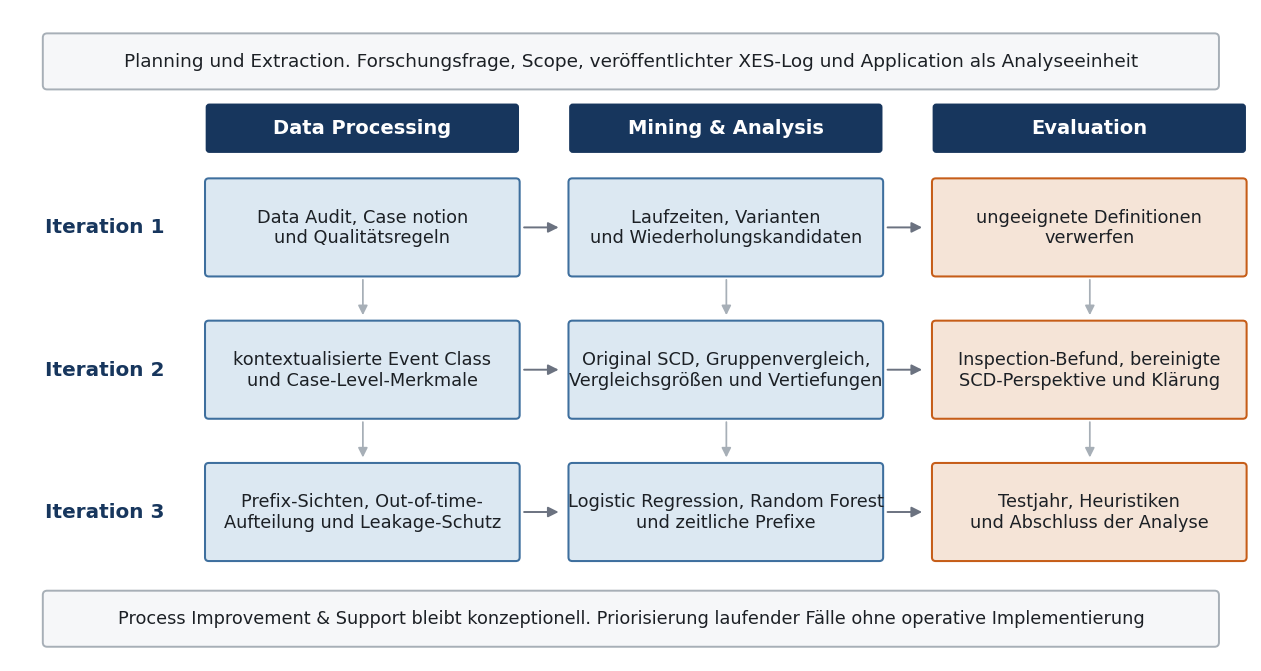

In [3]:
def figure_03_01(figures_dir: Path) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(11.5, 6.1))
    ax.set_xlim(0, 11.5)
    ax.set_ylim(0, 6.1)
    ax.axis('off')
    band_x, band_w, band_h = (0.35, 10.8, 0.48)
    header = FancyBboxPatch((band_x, 5.35), band_w, band_h, boxstyle='round,pad=0.02,rounding_size=0.04', facecolor=VERY_LIGHT, edgecolor=MID_GREY, linewidth=1.0)
    ax.add_patch(header)
    ax.text(band_x + band_w / 2, 5.59, 'Planning und Extraction. Forschungsfrage, Scope, veröffentlichter XES-Log und Application als Analyseeinheit', ha='center', va='center', fontsize=9.5, color=DARK)
    col_x = [1.85, 5.2, 8.55]
    col_w = 2.85
    for x, title in zip(col_x, ['Data Processing', 'Mining & Analysis', 'Evaluation']):
        patch = FancyBboxPatch((x, 4.76), col_w, 0.42, boxstyle='round,pad=0.01,rounding_size=0.025', facecolor=NAVY, edgecolor=NAVY)
        ax.add_patch(patch)
        ax.text(x + col_w / 2, 4.97, title, color=WHITE, fontweight='bold', ha='center', va='center', fontsize=10.0)
    rows = [(3.62, 'Iteration 1', ['Data Audit, Case notion\nund Qualitätsregeln', 'Laufzeiten, Varianten\nund Wiederholungskandidaten', 'ungeeignete Definitionen\nverwerfen']), (2.3, 'Iteration 2', ['kontextualisierte Event Class\nund Case-Level-Merkmale', 'Original SCD, Gruppenvergleich,\nVergleichsgrößen und Vertiefungen', 'Inspection-Befund, bereinigte\nSCD-Perspektive und Klärung']), (0.98, 'Iteration 3', ['Prefix-Sichten, Out-of-time-\nAufteilung und Leakage-Schutz', 'Logistic Regression, Random Forest\nund zeitliche Prefixe', 'Testjahr, Heuristiken\nund Abschluss der Analyse'])]
    for y, row_label, texts in rows:
        ax.text(0.35, y + 0.43, row_label, ha='left', va='center', color=NAVY, fontweight='bold', fontsize=10.3)
        for j, (x, text) in enumerate(zip(col_x, texts)):
            face = PALE_BLUE if j < 2 else PALE_ORANGE
            edge = BLUE if j < 2 else ORANGE
            box = FancyBboxPatch((x, y), col_w, 0.86, boxstyle='round,pad=0.025,rounding_size=0.035', facecolor=face, edgecolor=edge, linewidth=1.05)
            ax.add_patch(box)
            ax.text(x + col_w / 2, y + 0.43, text, ha='center', va='center', fontsize=9.15, linespacing=1.18, color=DARK)
            if j < 2:
                ax.add_patch(FancyArrowPatch((x + col_w + 0.03, y + 0.43), (col_x[j + 1] - 0.08, y + 0.43), arrowstyle='-|>', mutation_scale=11, linewidth=1.0, color=GREY))
    for x in [3.28, 6.63, 9.98]:
        for y1, y2 in [(3.6, 3.2), (2.28, 1.88)]:
            ax.add_patch(FancyArrowPatch((x, y1), (x, y2), arrowstyle='-|>', mutation_scale=10, linewidth=0.9, color=MID_GREY))
    footer = FancyBboxPatch((band_x, 0.18), band_w, band_h, boxstyle='round,pad=0.02,rounding_size=0.04', facecolor=VERY_LIGHT, edgecolor=MID_GREY, linewidth=1.0)
    ax.add_patch(footer)
    ax.text(band_x + band_w / 2, 0.42, 'Process Improvement & Support bleibt konzeptionell. Priorisierung laufender Fälle ohne operative Implementierung', ha='center', va='center', fontsize=9.15, color=DARK)
    save_figure(fig, 'fig_03_01_pm2_analysis_iterations_final', figures_dir)
    return fig

fig = figure_03_01(FIGURES)
plt.show()
plt.close(fig)


## Abbildung 3.2 Operationalisierung von Original SCD und inspection-bereinigter Perspektive

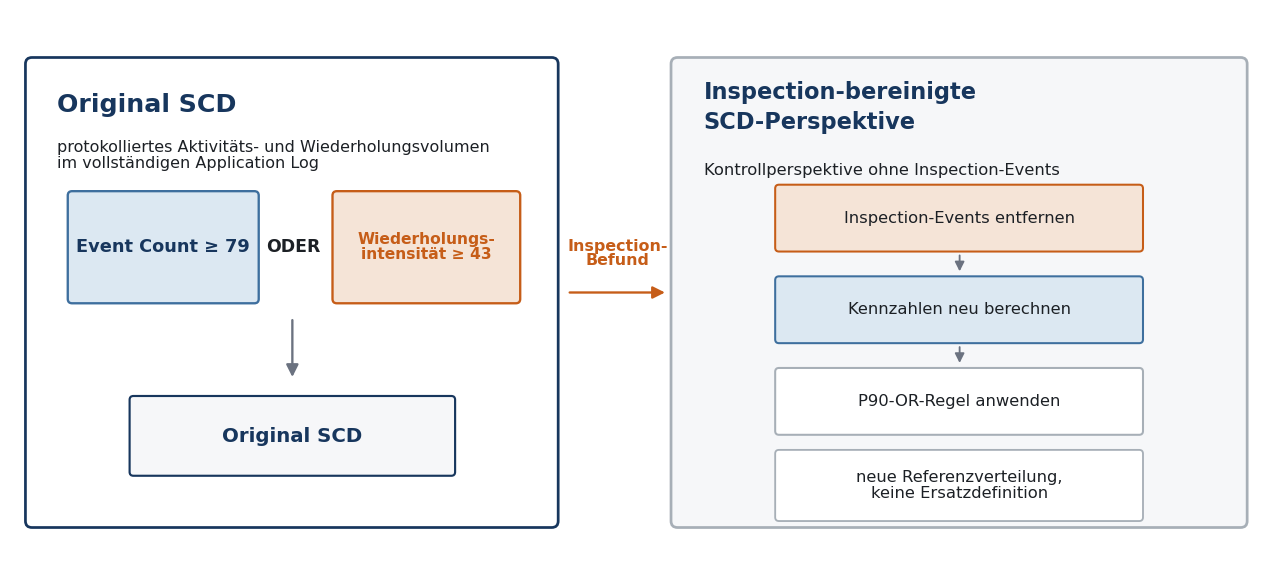

In [4]:
def figure_03_02(figures_dir: Path) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(11.6, 5.15))
    ax.set_xlim(0, 11.6)
    ax.set_ylim(0, 5.15)
    ax.axis('off')
    left = FancyBboxPatch((0.2, 0.35), 4.85, 4.3, boxstyle='round,pad=0.03,rounding_size=0.06', facecolor=WHITE, edgecolor=NAVY, linewidth=1.4)
    ax.add_patch(left)
    ax.text(0.46, 4.18, 'Original SCD', color=NAVY, fontsize=13.0, fontweight='bold')
    ax.text(0.46, 3.92, 'protokolliertes Aktivitäts- und Wiederholungsvolumen\nim vollständigen Application Log', color=DARK, fontsize=8.25, linespacing=1.12, va='top')
    m1 = FancyBboxPatch((0.58, 2.42), 1.72, 1.0, boxstyle='round,pad=0.02,rounding_size=0.04', facecolor=PALE_BLUE, edgecolor=BLUE, linewidth=1.2)
    m2 = FancyBboxPatch((3.02, 2.42), 1.69, 1.0, boxstyle='round,pad=0.02,rounding_size=0.04', facecolor=PALE_ORANGE, edgecolor=ORANGE, linewidth=1.2)
    ax.add_patch(m1)
    ax.add_patch(m2)
    ax.text(1.44, 2.92, 'Event Count ≥ 79', color=NAVY, fontweight='bold', ha='center', va='center', fontsize=9.15)
    ax.text(3.865, 2.92, 'Wiederholungs-\nintensität ≥ 43', color=ORANGE, fontweight='bold', ha='center', va='center', fontsize=8.0, linespacing=1.0)
    ax.text(2.64, 2.92, 'ODER', color=DARK, ha='center', va='center', fontweight='bold', fontsize=8.9)
    ax.add_patch(FancyArrowPatch((2.63, 2.28), (2.63, 1.68), arrowstyle='-|>', mutation_scale=13, linewidth=1.2, color=GREY))
    result = FancyBboxPatch((1.15, 0.82), 2.96, 0.7, boxstyle='round,pad=0.02,rounding_size=0.035', facecolor=VERY_LIGHT, edgecolor=NAVY, linewidth=1.1)
    ax.add_patch(result)
    ax.text(2.63, 1.17, 'Original SCD', ha='center', va='center', fontweight='bold', color=NAVY, fontsize=10.2)
    ax.add_patch(FancyArrowPatch((5.15, 2.5), (6.1, 2.5), arrowstyle='-|>', mutation_scale=13, linewidth=1.2, color=ORANGE))
    ax.text(5.63, 2.73, 'Inspection-\nBefund', ha='center', va='bottom', color=ORANGE, fontsize=8.15, fontweight='bold', linespacing=0.92)
    right = FancyBboxPatch((6.15, 0.35), 5.25, 4.3, boxstyle='round,pad=0.03,rounding_size=0.06', facecolor=VERY_LIGHT, edgecolor=MID_GREY, linewidth=1.4)
    ax.add_patch(right)
    ax.text(6.42, 4.3, 'Inspection-bereinigte', color=NAVY, fontsize=11.6, fontweight='bold')
    ax.text(6.42, 4.02, 'SCD-Perspektive', color=NAVY, fontsize=11.6, fontweight='bold')
    ax.text(6.42, 3.7, 'Kontrollperspektive ohne Inspection-Events', color=DARK, fontsize=8.45, va='top')
    steps = [(2.9, 'Inspection-Events entfernen', PALE_ORANGE, ORANGE), (2.05, 'Kennzahlen neu berechnen', PALE_BLUE, BLUE), (1.2, 'P90-OR-Regel anwenden', WHITE, MID_GREY)]
    for y, text, face, edge in steps:
        patch = FancyBboxPatch((7.1, y), 3.35, 0.58, boxstyle='round,pad=0.02,rounding_size=0.035', facecolor=face, edgecolor=edge, linewidth=1.05)
        ax.add_patch(patch)
        ax.text(8.78, y + 0.29, text, ha='center', va='center', fontsize=8.45, color=DARK)
    for y1, y2 in [(2.88, 2.66), (2.03, 1.81)]:
        ax.add_patch(FancyArrowPatch((8.78, y1), (8.78, y2), arrowstyle='-|>', mutation_scale=10, linewidth=0.95, color=GREY))
    note = FancyBboxPatch((7.1, 0.4), 3.35, 0.62, boxstyle='round,pad=0.02,rounding_size=0.035', facecolor=WHITE, edgecolor=MID_GREY, linewidth=0.95)
    ax.add_patch(note)
    ax.text(8.78, 0.71, 'neue Referenzverteilung,\nkeine Ersatzdefinition', ha='center', va='center', color=DARK, fontsize=8.45, linespacing=1.08)
    save_figure(fig, 'fig_03_02_scd_operationalization_final', figures_dir)
    return fig

fig = figure_03_02(FIGURES)
plt.show()
plt.close(fig)


## Abbildung 4.1 Datenarchitektur und analytische Sichten

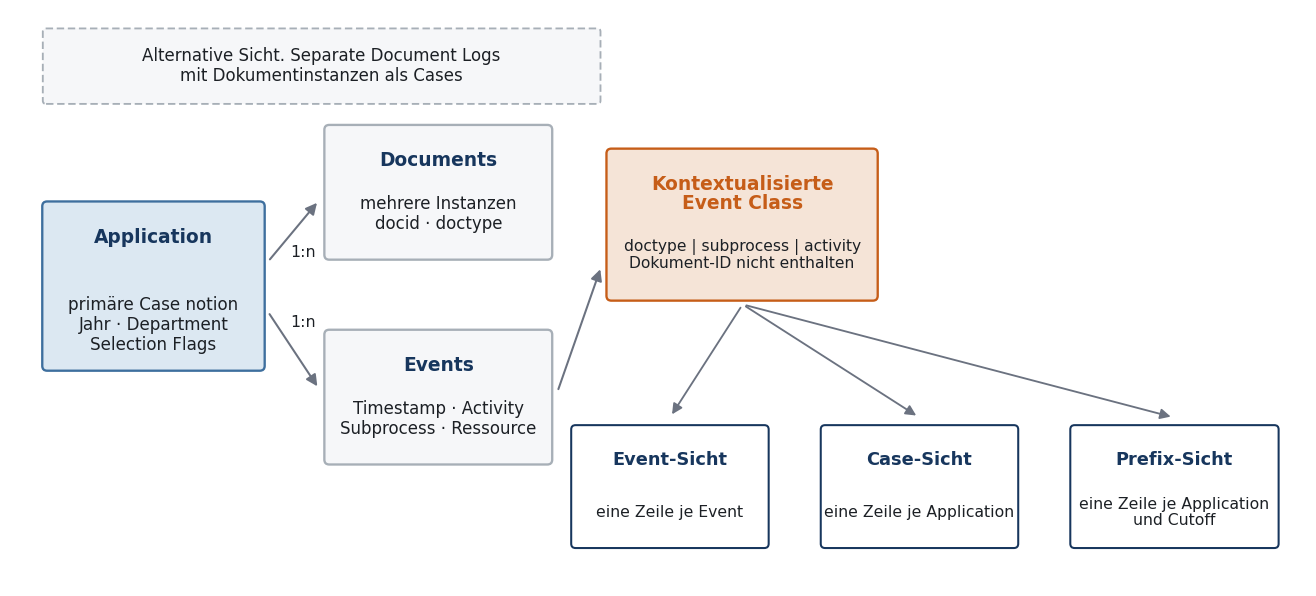

In [5]:
def figure_04_01(figures_dir: Path) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(12.0, 5.4))
    ax.set_xlim(0, 12.0)
    ax.set_ylim(0, 5.4)
    ax.axis('off')
    note = FancyBboxPatch((0.35, 4.52), 5.1, 0.66, boxstyle='round,pad=0.02,rounding_size=0.03', facecolor=VERY_LIGHT, edgecolor=MID_GREY, linewidth=0.95, linestyle=(0, (4, 2)))
    ax.add_patch(note)
    ax.text(2.9, 4.85, 'Alternative Sicht. Separate Document Logs\nmit Dokumentinstanzen als Cases', ha='center', va='center', fontsize=8.55, color=DARK, linespacing=1.12)
    box_specs = [(0.35, 2.05, 2.0, 1.52, 'Application', 'primäre Case notion\nJahr · Department\nSelection Flags', PALE_BLUE, BLUE, 8.65), (2.95, 3.08, 2.05, 1.2, 'Documents', 'mehrere Instanzen\ndocid · doctype', VERY_LIGHT, MID_GREY, 8.55), (2.95, 1.18, 2.05, 1.2, 'Events', 'Timestamp · Activity\nSubprocess · Ressource', VERY_LIGHT, MID_GREY, 8.55), (5.55, 2.7, 2.45, 1.36, 'Kontextualisierte\nEvent Class', 'doctype | subprocess | activity\nDokument-ID nicht enthalten', PALE_ORANGE, ORANGE, 8.0)]
    relation_arrows = [((2.4, 3.03), (2.88, 3.61)), ((2.4, 2.58), (2.88, 1.85)), ((5.07, 1.82), (5.48, 3.0))]
    for start, end in relation_arrows:
        ax.add_patch(FancyArrowPatch(start, end, arrowstyle='-|>', mutation_scale=12, linewidth=1.05, color=GREY))
    ax.text(2.73, 3.12, '1:n', color=DARK, fontsize=8.15, ha='center', va='center')
    ax.text(2.73, 2.47, '1:n', color=DARK, fontsize=8.15, ha='center', va='center')
    for x, y, w, h, title, body, face, edge, fs in box_specs:
        patch = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.025,rounding_size=0.045', facecolor=face, edgecolor=edge, linewidth=1.2)
        ax.add_patch(patch)
        ax.text(x + w / 2, y + h - 0.22, title, ha='center', va='top', fontweight='bold', color=NAVY if edge != ORANGE else ORANGE, fontsize=9.55, linespacing=1.0)
        ax.text(x + w / 2, y + 0.4, body, ha='center', va='center', fontsize=fs, linespacing=1.12, color=DARK)
    views = [(5.22, 0.4, 1.78, 1.1, 'Event-Sicht', 'eine Zeile je Event'), (7.52, 0.4, 1.78, 1.1, 'Case-Sicht', 'eine Zeile je Application'), (9.82, 0.4, 1.88, 1.1, 'Prefix-Sicht', 'eine Zeile je Application\nund Cutoff')]
    start = (6.78, 2.64)
    for end in [(6.11, 1.59), (8.41, 1.59), (10.76, 1.59)]:
        ax.add_patch(FancyArrowPatch(start, end, arrowstyle='-|>', mutation_scale=11, linewidth=0.95, color=GREY))
    for x, y, w, h, title, body in views:
        patch = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.02,rounding_size=0.04', facecolor=WHITE, edgecolor=NAVY, linewidth=1.05)
        ax.add_patch(patch)
        ax.text(x + w / 2, y + h - 0.22, title, ha='center', va='top', color=NAVY, fontweight='bold', fontsize=9.15)
        ax.text(x + w / 2, y + 0.31, body, ha='center', va='center', fontsize=8.05, linespacing=1.1, color=DARK)
    save_figure(fig, 'fig_04_01_data_architecture_final', figures_dir)
    return fig

fig = figure_04_01(FIGURES)
plt.show()
plt.close(fig)


## Abbildung 5.1 Verdichteter Prozessüberblick

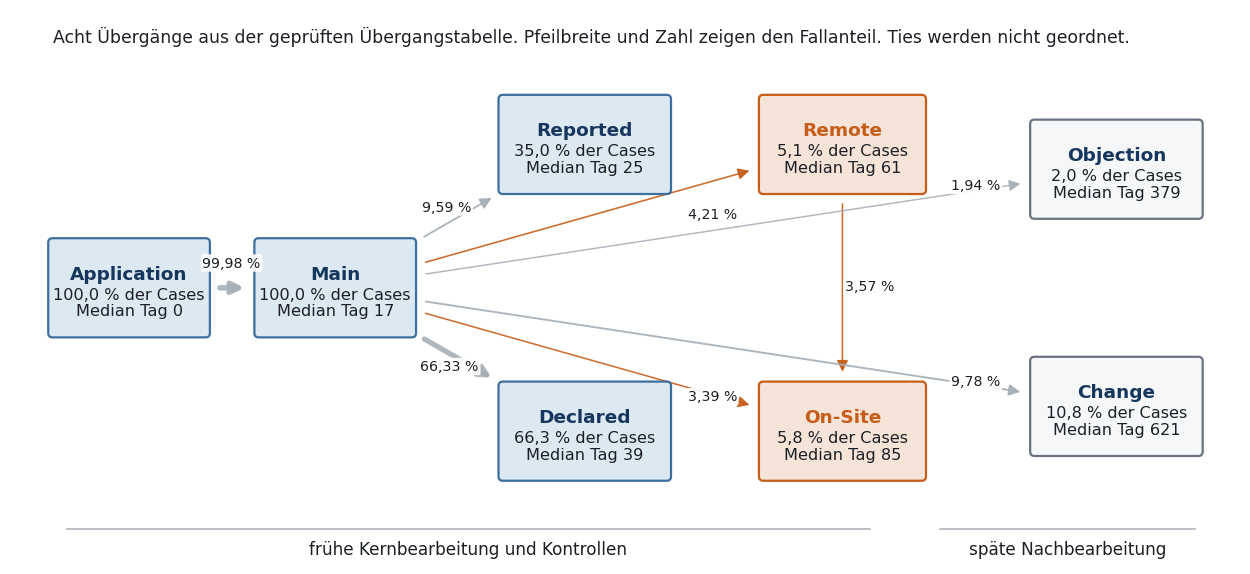

In [6]:
def figure_05_01(nodes: pd.DataFrame, edges: pd.DataFrame, figures_dir: Path) -> plt.Figure:
    if 'subprocess' in nodes.columns:
        nodes = nodes.set_index('subprocess')
    selected_edges = [('Application', 'Main'), ('Main', 'Reported'), ('Main', 'Declared'), ('Main', 'Remote'), ('Main', 'On-Site'), ('Remote', 'On-Site'), ('Main', 'Objection'), ('Main', 'Change')]
    edge_lookup = {(r.source, r.target): r for r in edges.itertuples()}
    fig, ax = plt.subplots(figsize=(11.4, 5.2))
    ax.set_xlim(0, 11.4)
    ax.set_ylim(0, 5.2)
    ax.axis('off')
    positions = {'Application': (0.4, 2.15), 'Main': (2.3, 2.15), 'Reported': (4.55, 3.48), 'Declared': (4.55, 0.82), 'Remote': (6.95, 3.48), 'On-Site': (6.95, 0.82), 'Objection': (9.45, 3.25), 'Change': (9.45, 1.05)}
    box_sizes = {'Application': (1.45, 0.88), 'Main': (1.45, 0.88), 'Reported': (1.55, 0.88), 'Declared': (1.55, 0.88), 'Remote': (1.5, 0.88), 'On-Site': (1.5, 0.88), 'Objection': (1.55, 0.88), 'Change': (1.55, 0.88)}
    label_positions = {('Application', 'Main'): (2.07, 2.82), ('Main', 'Reported'): (4.05, 3.34), ('Main', 'Declared'): (4.08, 1.86), ('Main', 'Remote'): (6.5, 3.27), ('Main', 'On-Site'): (6.5, 1.58), ('Remote', 'On-Site'): (7.95, 2.6), ('Main', 'Objection'): (8.93, 3.54), ('Main', 'Change'): (8.93, 1.72)}
    for source, target in selected_edges:
        row = edge_lookup.get((source, target))
        share = float(row.case_share_pct) if row is not None else 1.0
        linewidth = 0.7 + 2.1 * min(share, 70) / 70
        color = ORANGE if target in {'Remote', 'On-Site'} else MID_GREY
        start, end = _box_connector(positions, box_sizes, source, target)
        ax.add_patch(FancyArrowPatch(start, end, arrowstyle='-|>', mutation_scale=12.0, linewidth=linewidth, color=color, alpha=0.9, connectionstyle='arc3,rad=0.0', zorder=1))
        lx, ly = label_positions[source, target]
        ax.text(lx, ly, de_pct(share, 2), ha='center', va='center', fontsize=7.25, color=DARK, bbox={'boxstyle': 'round,pad=0.12', 'facecolor': WHITE, 'edgecolor': 'none', 'alpha': 0.92}, zorder=5)
    for name, (x, y) in positions.items():
        w, h = box_sizes[name]
        if name in {'Remote', 'On-Site'}:
            face, edge = (PALE_ORANGE, ORANGE)
        elif name in {'Objection', 'Change'}:
            face, edge = (VERY_LIGHT, GREY)
        else:
            face, edge = (PALE_BLUE, BLUE)
        patch = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.02,rounding_size=0.04', facecolor=face, edgecolor=edge, linewidth=1.15, zorder=3)
        ax.add_patch(patch)
        row = nodes.loc[name]
        ax.text(x + w / 2, y + h - 0.23, name, ha='center', va='top', fontweight='bold', color=NAVY if edge != ORANGE else ORANGE, fontsize=9.5, zorder=4)
        ax.text(x + w / 2, y + 0.3, f'{de_pct(row.case_share_pct, 1)} der Cases\nMedian Tag {de_num(row.median_first_elapsed_days, 0)}', ha='center', va='center', fontsize=8.3, linespacing=1.15, color=DARK, zorder=4)
    ax.plot([0.55, 7.95], [0.35, 0.35], color=MID_GREY, linewidth=0.8)
    ax.plot([8.6, 10.95], [0.35, 0.35], color=MID_GREY, linewidth=0.8)
    ax.text(4.25, 0.16, 'frühe Kernbearbeitung und Kontrollen', ha='center', va='center', color=DARK, fontsize=8.7)
    ax.text(9.78, 0.16, 'späte Nachbearbeitung', ha='center', va='center', color=DARK, fontsize=8.7)
    ax.text(0.42, 4.92, 'Acht Übergänge aus der geprüften Übergangstabelle. Pfeilbreite und Zahl zeigen den Fallanteil. Ties werden nicht geordnet.', ha='left', va='center', fontsize=8.9, color=DARK)
    save_figure(fig, 'fig_05_01_process_overview_final', figures_dir)
    return fig

fig = figure_05_01(nodes, edges, FIGURES)
plt.show()
plt.close(fig)


## Abbildung 5.2 Umfang und Zusammensetzung von Original SCD

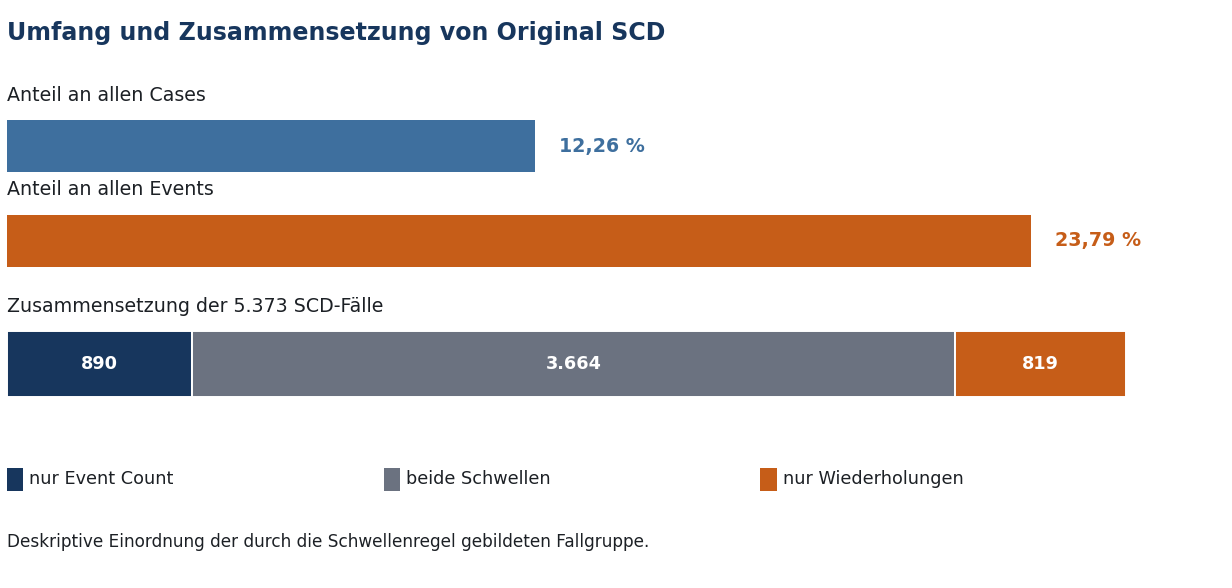

In [7]:
def figure_05_02a(components: pd.DataFrame, metrics: pd.DataFrame, figures_dir: Path) -> plt.Figure:
    metric_lookup = dict(zip(metrics['metric'], metrics['value']))
    case_share = float(metric_lookup.get('primary_label_share_pct', 12.2646))
    event_share = float(metric_lookup.get('primary_positive_event_share_pct', 23.79))
    comp_map = {'nur Event Count >= P90': 'nur Event Count', 'beide Komponenten: Event Count und Combined Rework >= P90': 'beide Schwellen', 'nur Combined Rework >= P90': 'nur Wiederholungen'}
    comp = components[components['component'].isin(comp_map)].copy()
    comp['short'] = comp['component'].map(comp_map)
    comp_order = ['nur Event Count', 'beide Schwellen', 'nur Wiederholungen']
    comp = comp.set_index('short').loc[comp_order].reset_index()
    fig, ax = plt.subplots(figsize=(9.0, 4.4))
    ax.set_xlim(0, 28.3)
    ax.set_ylim(-0.85, 3.15)
    ax.axis('off')
    ax.text(0, 2.92, 'Umfang und Zusammensetzung von Original SCD', fontweight='bold', color=NAVY, fontsize=12.2)
    for y, value, label, color in [(2.18, case_share, 'Anteil an allen Cases', BLUE), (1.52, event_share, 'Anteil an allen Events', ORANGE)]:
        ax.barh(y, value, height=0.36, color=color)
        ax.text(0, y + 0.29, label, ha='left', va='bottom', fontsize=9.8, color=DARK)
        ax.text(value + 0.55, y, de_pct(value, 2), ha='left', va='center', fontweight='bold', color=color, fontsize=9.8)
    x0, y0, total_w, h = (0.0, 0.43, 26.0, 0.46)
    colors = [NAVY, GREY, ORANGE]
    current = x0
    for (_, row), color in zip(comp.iterrows(), colors):
        width = total_w * row['cases'] / comp['cases'].sum()
        ax.add_patch(Rectangle((current, y0), width, h, facecolor=color, edgecolor=WHITE, linewidth=1.0))
        ax.text(current + width / 2, y0 + h / 2, de_num(row['cases']), ha='center', va='center', color=WHITE, fontweight='bold', fontsize=9.1)
        current += width
    ax.text(0, 1.0, 'Zusammensetzung der 5.373 SCD-Fälle', ha='left', va='bottom', fontsize=9.8, color=DARK)
    for i, (label, color) in enumerate(zip(comp_order, colors)):
        x = i * 8.75
        ax.add_patch(Rectangle((x, -0.22), 0.38, 0.16, facecolor=color, edgecolor='none'))
        ax.text(x + 0.52, -0.14, label, ha='left', va='center', fontsize=9.1, color=DARK)
    ax.text(0, -0.58, 'Deskriptive Einordnung der durch die Schwellenregel gebildeten Fallgruppe.', ha='left', va='center', fontsize=8.7, color=DARK)
    fig.tight_layout()
    save_figure(fig, 'fig_05_02a_scd_scope_final', figures_dir)
    return fig

fig = figure_05_02a(components, executive_metrics, FIGURES)
plt.show()
plt.close(fig)


## Abbildung 5.3 Ergänzendes Strukturprofil der SCD-Fälle

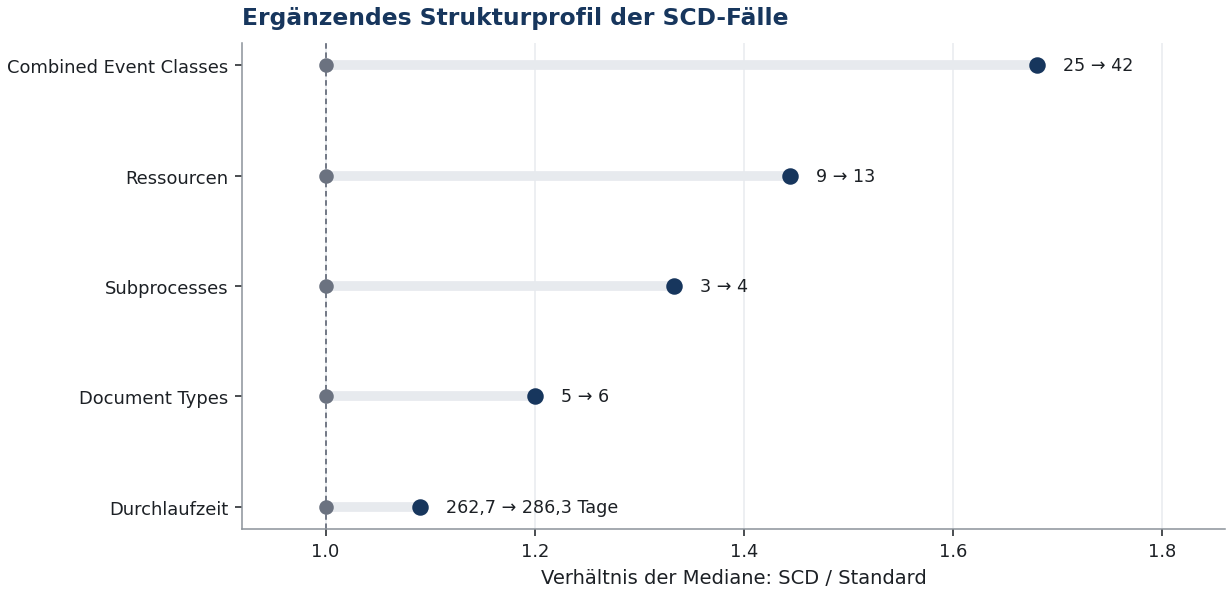

In [8]:
def figure_05_02b(groups: pd.DataFrame, figures_dir: Path) -> plt.Figure:
    profile_metrics = [('n_combined_activity_labels', 'Combined Event Classes'), ('n_resources', 'Ressourcen'), ('n_subprocesses', 'Subprocesses'), ('n_doctypes', 'Document Types'), ('duration_days', 'Durchlaufzeit')]
    profile = groups.set_index('metric').loc[[x[0] for x in profile_metrics]].copy()
    profile['label'] = [x[1] for x in profile_metrics]
    fig, ax = plt.subplots(figsize=(9.0, 4.45))
    y = np.arange(len(profile))
    ratios = profile['median_ratio_pos_neg'].astype(float).to_numpy()
    ax.hlines(y, 1.0, ratios, color=LIGHT_GREY, linewidth=5.0, zorder=1)
    ax.scatter(np.ones_like(y), y, color=GREY, s=42, zorder=3)
    ax.scatter(ratios, y, color=NAVY, s=56, zorder=4)
    ax.axvline(1.0, color=GREY, linestyle=(0, (3, 2)), linewidth=0.95)
    ax.set_yticks(y, profile['label'])
    ax.invert_yaxis()
    ax.set_xlim(0.92, 1.86)
    ax.set_xlabel('Verhältnis der Mediane: SCD / Standard')
    ax.set_title('Ergänzendes Strukturprofil der SCD-Fälle', loc='left', color=NAVY, fontweight='bold', pad=10)
    clean_axis(ax, 'x')
    for yi, row in enumerate(profile.itertuples()):
        standard = row.median_negative
        scd = row.median_positive
        decimals = 1 if row.Index == 'duration_days' else 0
        suffix = ' Tage' if row.Index == 'duration_days' else ''
        ax.text(row.median_ratio_pos_neg + 0.025, yi, f'{de_num(standard, decimals)} → {de_num(scd, decimals)}{suffix}', va='center', ha='left', fontsize=9.0, color=DARK)
    fig.tight_layout()
    save_figure(fig, 'fig_05_02b_scd_structure_profile_final', figures_dir)
    return fig

fig = figure_05_02b(groups, FIGURES)
plt.show()
plt.close(fig)


## Abbildung 5.4 Original SCD und inspection-bereinigte Perspektive

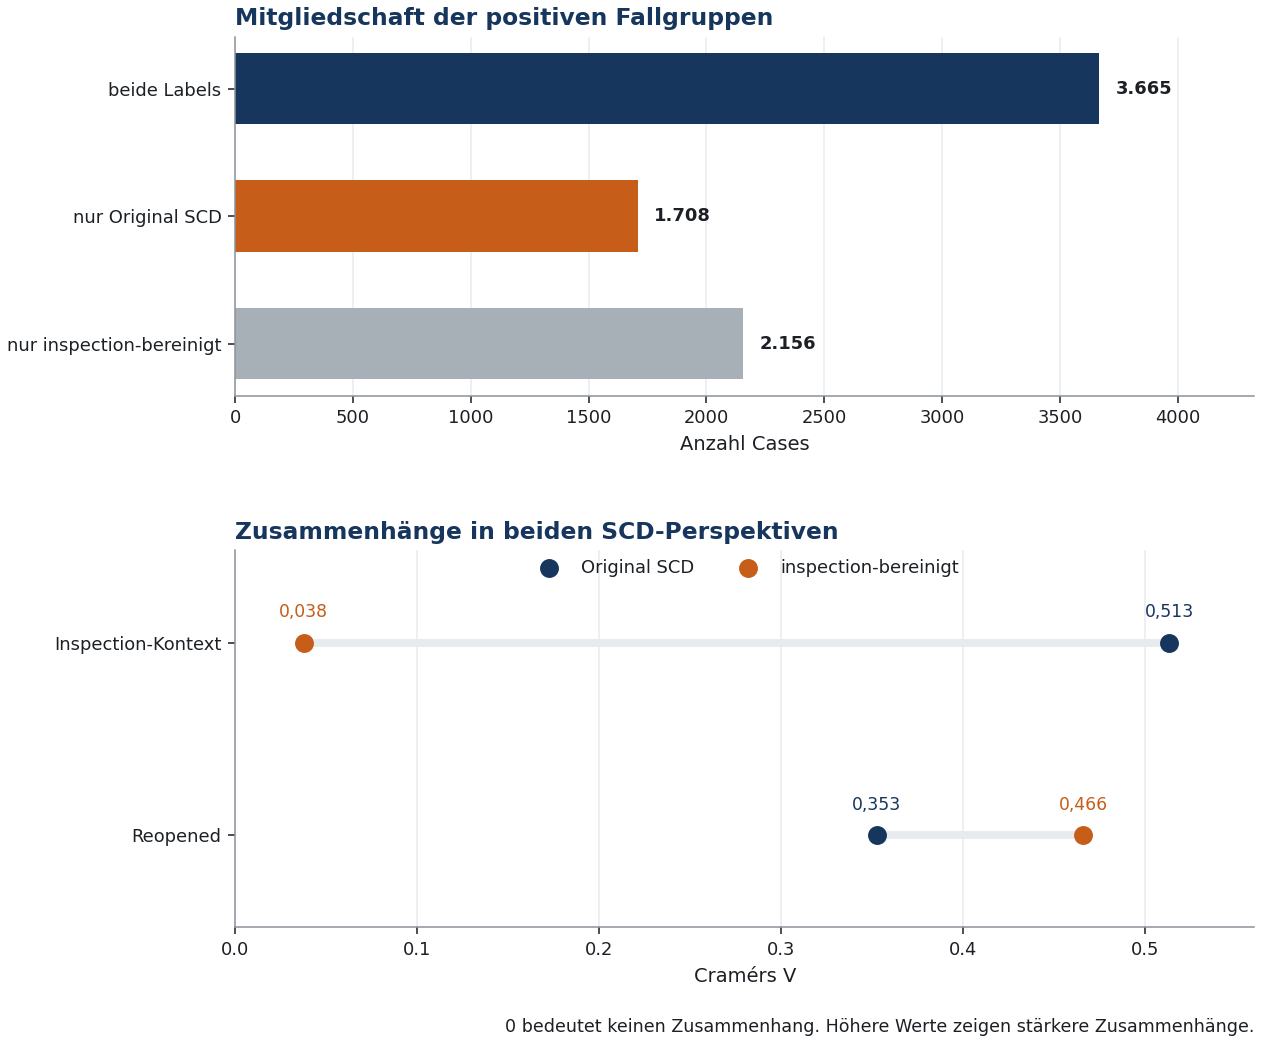

In [9]:
def figure_05_03(transitions: pd.DataFrame, effects: pd.DataFrame, figures_dir: Path) -> plt.Figure:
    order = ['Beide Labels', 'Nur originales SCD', 'Nur residualisiertes SCD']
    trans = transitions.set_index('Gruppe').loc[order].reset_index()
    labels = ['beide Labels', 'nur Original SCD', 'nur inspection-bereinigt']
    colors = [NAVY, ORANGE, MID_GREY]
    fig = plt.figure(figsize=(9.1, 7.4))
    gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.05], hspace=0.42)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax1.barh(np.arange(3), trans['Fälle'], color=colors, height=0.56)
    ax1.set_yticks(np.arange(3), labels)
    ax1.invert_yaxis()
    ax1.set_xlabel('Anzahl Cases')
    ax1.set_title('Mitgliedschaft der positiven Fallgruppen', loc='left', color=NAVY, fontweight='bold')
    clean_axis(ax1, 'x')
    ax1.set_xlim(0, float(trans['Fälle'].max()) * 1.18)
    for yi, value in enumerate(trans['Fälle']):
        ax1.text(value + 70, yi, de_num(value), va='center', ha='left', fontsize=9.2, fontweight='bold', color=DARK)
    pairs = [('Inspection-Kontext', 'Inspection-Kontext vs. originales SCD', 'Inspection-Kontext vs. residualisiertes SCD'), ('Reopened', 'Reopened vs. originales SCD', 'Reopened vs. residualisiertes SCD')]
    y_positions = np.arange(len(pairs))[::-1]
    original_values: list[float] = []
    residual_values: list[float] = []
    for _, key_original, key_residual in pairs:
        original_values.append(float(effects.loc[effects['Vergleich'] == key_original, 'Wert'].iloc[0]))
        residual_values.append(float(effects.loc[effects['Vergleich'] == key_residual, 'Wert'].iloc[0]))
    for y, original, residual in zip(y_positions, original_values, residual_values):
        ax2.hlines(y, min(original, residual), max(original, residual), color=LIGHT_GREY, linewidth=4.0, zorder=1)
    ax2.scatter(original_values, y_positions, s=76, color=NAVY, zorder=3, label='Original SCD')
    ax2.scatter(residual_values, y_positions, s=76, color=ORANGE, zorder=3, label='inspection-bereinigt')
    ax2.set_yticks(y_positions, [p[0] for p in pairs])
    ax2.set_xlim(0, 0.56)
    ax2.set_ylim(-0.48, 1.48)
    ax2.set_xlabel('Cramérs V')
    ax2.set_title('Zusammenhänge in beiden SCD-Perspektiven', loc='left', color=NAVY, fontweight='bold')
    clean_axis(ax2, 'x')
    ax2.legend(frameon=False, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02), labelcolor=DARK)
    for y, original, residual in zip(y_positions, original_values, residual_values):
        ax2.annotate(de_num(original, 3), (original, y), xytext=(0, 11), textcoords='offset points', ha='center', va='bottom', fontsize=8.9, color=NAVY)
        residual_offset = -17 if abs(original - residual) < 0.08 else 11
        ax2.annotate(de_num(residual, 3), (residual, y), xytext=(0, residual_offset), textcoords='offset points', ha='center', va='bottom' if residual_offset > 0 else 'top', fontsize=8.9, color=ORANGE)
    ax2.text(1.0, -0.24, '0 bedeutet keinen Zusammenhang. Höhere Werte zeigen stärkere Zusammenhänge.', transform=ax2.transAxes, ha='right', va='top', fontsize=9.0, color=DARK)
    fig.subplots_adjust(left=0.18, right=0.98, top=0.96, bottom=0.1)
    save_figure(fig, 'fig_05_03_original_residual_scd_final', figures_dir)
    return fig

fig = figure_05_03(transitions, effects, FIGURES)
plt.show()
plt.close(fig)


## Abbildung 5.5 Inspection sowie Change und Objection

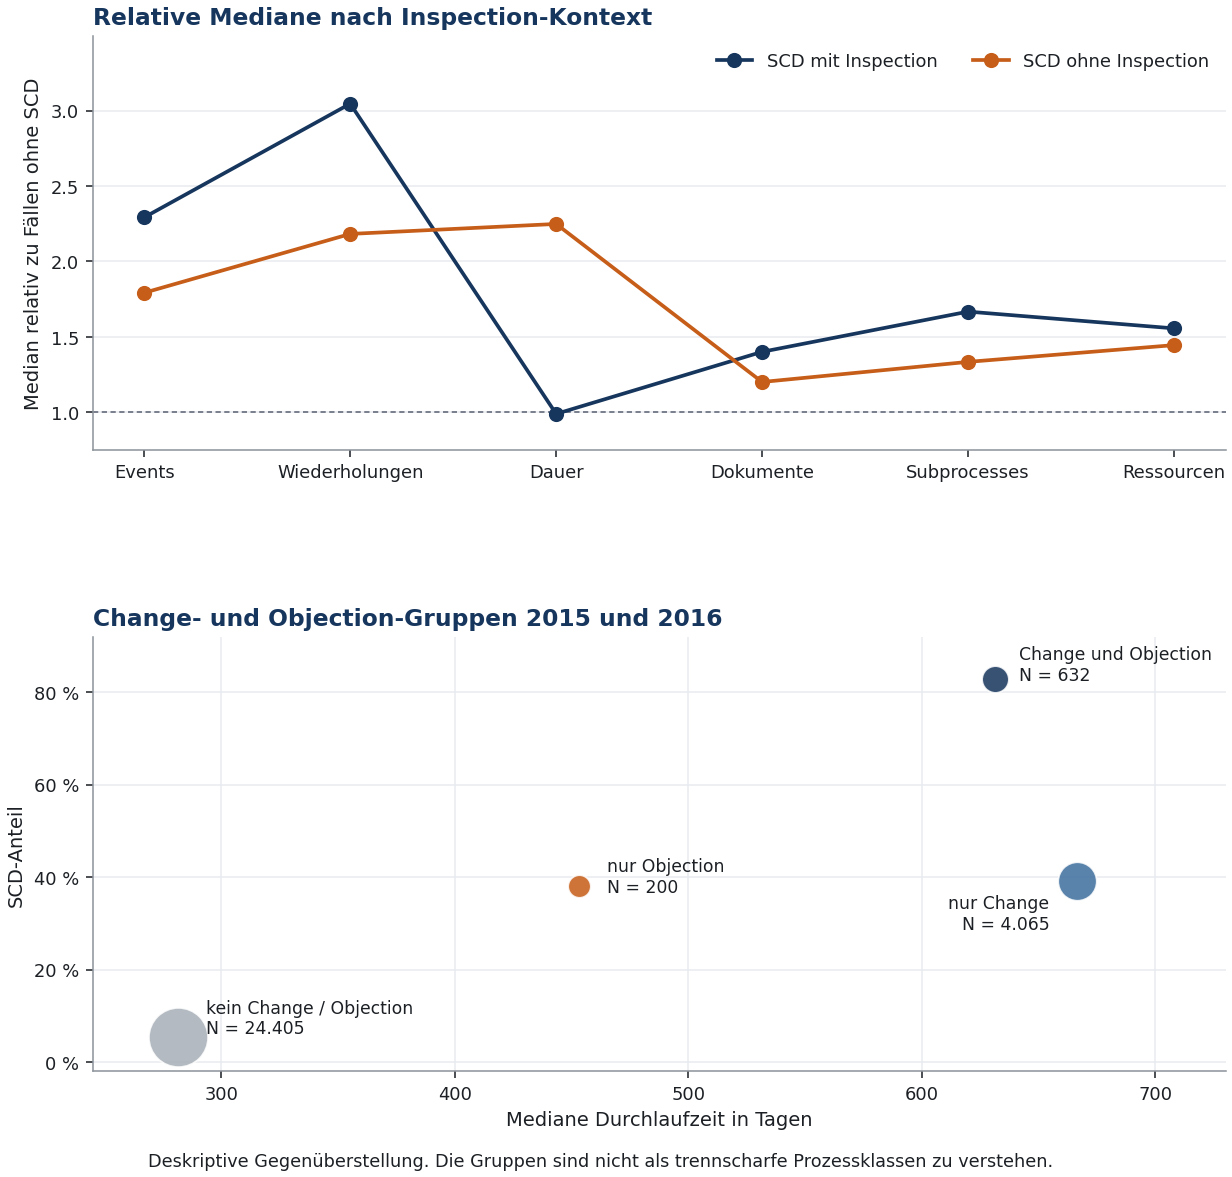

In [10]:
def figure_05_04(inspection: pd.DataFrame, change: pd.DataFrame, figures_dir: Path) -> plt.Figure:
    base_group = inspection[inspection['group'] == 'neither'].set_index('metric')
    with_insp = inspection[inspection['group'] == 'SCD_inspection'].set_index('metric')
    without_insp = inspection[inspection['group'] == 'SCD_no_inspection'].set_index('metric')
    metric_def = [('event_count', 'Events'), ('combined_rework_extra', 'Wiederholungen'), ('duration_days', 'Dauer'), ('n_documents', 'Dokumente'), ('n_subprocesses', 'Subprocesses'), ('n_resources', 'Ressourcen')]
    ratio_insp = [with_insp.loc[m, 'median'] / base_group.loc[m, 'median'] for m, _ in metric_def]
    ratio_no = [without_insp.loc[m, 'median'] / base_group.loc[m, 'median'] for m, _ in metric_def]
    fig = plt.figure(figsize=(9.3, 8.6))
    gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.05], hspace=0.44)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    x = np.arange(len(metric_def))
    ax1.axhline(1.0, color=GREY, linestyle=(0, (3, 2)), linewidth=0.9)
    ax1.plot(x, ratio_insp, marker='o', color=NAVY, linewidth=1.9, markersize=6.8, label='SCD mit Inspection')
    ax1.plot(x, ratio_no, marker='o', color=ORANGE, linewidth=1.9, markersize=6.8, label='SCD ohne Inspection')
    ax1.set_xticks(x, [label for _, label in metric_def])
    ax1.set_ylabel('Median relativ zu Fällen ohne SCD')
    ax1.set_title('Relative Mediane nach Inspection-Kontext', loc='left', color=NAVY, fontweight='bold')
    ax1.set_ylim(0.75, max(max(ratio_insp), max(ratio_no)) + 0.45)
    clean_axis(ax1, 'y')
    ax1.legend(frameon=False, loc='upper right', ncol=2, labelcolor=DARK)
    sub = change[change['population'] == '2015_2016'].copy()
    label_map = {'none': 'kein Change / Objection', 'change_only': 'nur Change', 'objection_only': 'nur Objection', 'change_and_objection': 'Change und Objection'}
    color_map = {'none': MID_GREY, 'change_only': BLUE, 'objection_only': ORANGE, 'change_and_objection': NAVY}
    for row in sub.itertuples():
        size = 75 + 850 * (row.n_cases / sub.n_cases.max()) ** 0.55
        ax2.scatter(row.median_duration, row.scd_rate_pct, s=size, color=color_map[row.reopened_type], alpha=0.86, edgecolor=WHITE, linewidth=0.9, zorder=3)
        if row.reopened_type == 'none':
            dx, dy, ha = (12, 4, 'left')
        elif row.reopened_type == 'change_only':
            dx, dy, ha = (-12, -7, 'right')
        elif row.reopened_type == 'objection_only':
            dx, dy, ha = (12, 2, 'left')
        else:
            dx, dy, ha = (10, 3, 'left')
        ax2.text(row.median_duration + dx, row.scd_rate_pct + dy, f'{label_map[row.reopened_type]}\nN = {de_num(row.n_cases)}', ha=ha, va='center', fontsize=8.9, color=DARK)
    ax2.set_xlabel('Mediane Durchlaufzeit in Tagen')
    ax2.set_ylabel('SCD-Anteil')
    ax2.set_yticks([0, 20, 40, 60, 80], ['0 %', '20 %', '40 %', '60 %', '80 %'])
    ax2.set_title('Change- und Objection-Gruppen 2015 und 2016', loc='left', color=NAVY, fontweight='bold')
    ax2.set_xlim(245, 730)
    ax2.set_ylim(-2, 92)
    clean_axis(ax2, 'both')
    fig.text(0.5, 0.018, 'Deskriptive Gegenüberstellung. Die Gruppen sind nicht als trennscharfe Prozessklassen zu verstehen.', ha='center', va='bottom', fontsize=9.1, color=DARK)
    fig.subplots_adjust(left=0.11, right=0.98, top=0.96, bottom=0.1)
    save_figure(fig, 'fig_05_04_complexity_mechanisms_final', figures_dir)
    return fig

fig = figure_05_04(inspection, change, FIGURES)
plt.show()
plt.close(fig)


## Abbildung 5.6 Auswahl von Modell und Beobachtungsfenster

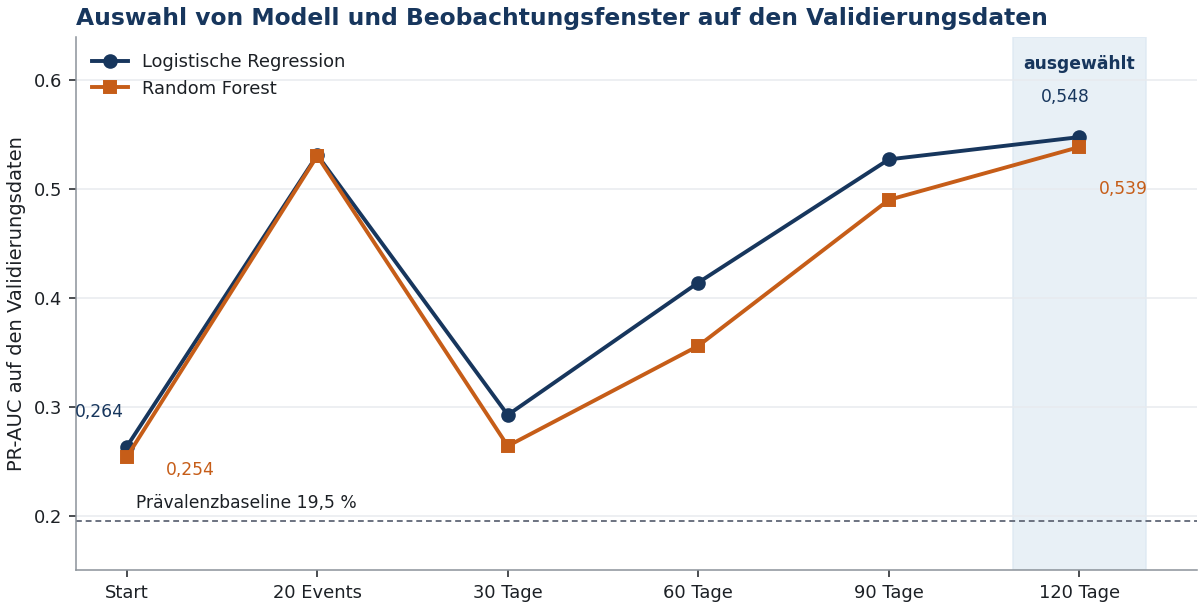

In [11]:
def figure_05_05(candidates: pd.DataFrame, figures_dir: Path) -> plt.Figure:
    scd = candidates[(candidates['target'] == 'label_scd_p90_or_global') & (candidates['scenario'] == 'observed_prefix') & (candidates['split'] == 'validation') & candidates['model'].isin(['logreg_balanced', 'rf_balanced'])].copy()
    order = ['static_first_event', 'event20', 'time30d', 'time60d', 'time90d', 'time120d']
    labels = ['Start', '20 Events', '30 Tage', '60 Tage', '90 Tage', '120 Tage']
    scd['prefix_id'] = pd.Categorical(scd['prefix_id'], categories=order, ordered=True)
    scd = scd.sort_values('prefix_id')
    fig, ax = plt.subplots(figsize=(8.8, 4.55))
    endpoint_labels = {'logreg_balanced': {0: (-14, 13, 'center', 'bottom'), 5: (-7, 16, 'center', 'bottom')}, 'rf_balanced': {0: (20, -2, 'left', 'top'), 5: (10, -17, 'left', 'top')}}
    for model, label, color, marker in [('logreg_balanced', 'Logistische Regression', NAVY, 'o'), ('rf_balanced', 'Random Forest', ORANGE, 's')]:
        sub = scd[scd['model'] == model].set_index('prefix_id').reindex(order)
        values = sub['pr_auc_average_precision'].to_numpy()
        ax.plot(np.arange(len(order)), values, marker=marker, color=color, linewidth=2.0, markersize=6.5, label=label)
        for xi in (0, len(order) - 1):
            value = values[xi]
            dx, dy, ha, va = endpoint_labels[model][xi]
            ax.annotate(de_num(value, 3), (xi, value), xytext=(dx, dy), textcoords='offset points', ha=ha, va=va, fontsize=8.8, color=color)
    baseline = float(scd['prevalence_pct'].iloc[0]) / 100
    ax.axhline(baseline, color=GREY, linestyle=(0, (3, 2)), linewidth=1.0)
    ax.text(0.05, baseline + 0.012, f'Prävalenzbaseline {de_pct(baseline * 100, 1)}', color=DARK, fontsize=8.8)
    ax.axvspan(4.65, 5.35, color=PALE_BLUE, alpha=0.65, zorder=0)
    ax.text(5, 0.615, 'ausgewählt', ha='center', va='center', fontsize=8.8, color=NAVY, fontweight='bold')
    ax.set_xticks(np.arange(len(order)), labels)
    ax.set_ylabel('PR-AUC auf den Validierungsdaten')
    ax.set_ylim(0.15, 0.64)
    ax.set_title('Auswahl von Modell und Beobachtungsfenster auf den Validierungsdaten', loc='left', color=NAVY, fontweight='bold')
    clean_axis(ax, 'y')
    ax.legend(frameon=False, loc='upper left', labelcolor=DARK)
    fig.tight_layout()
    save_figure(fig, 'fig_05_05_validation_prefix_selection_final', figures_dir)
    return fig

fig = figure_05_05(candidates, FIGURES)
plt.show()
plt.close(fig)


## Abbildung 5.7 Modell und Heuristiken im Testjahr

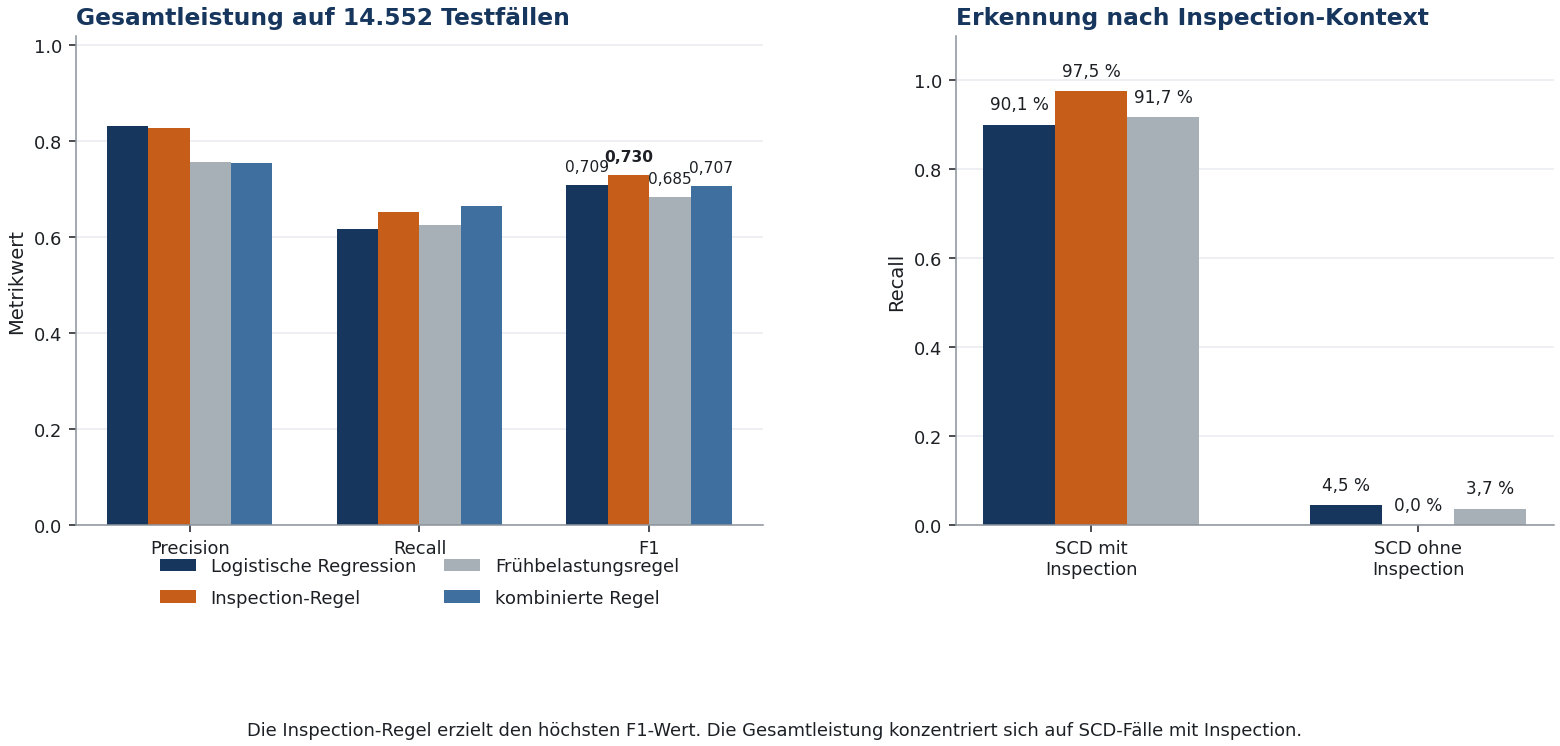

In [12]:
def figure_05_06(metrics: pd.DataFrame, subgroups: pd.DataFrame, figures_dir: Path) -> plt.Figure:
    subgroups = subgroups[subgroups['group_variable'] == 'has_inspection_event_context'].copy()
    method_order = ['Final Logistic Regression', 'Inspection heuristic', 'Early-load heuristic', 'Combined heuristic']
    labels = {'Final Logistic Regression': 'Logistische Regression', 'Inspection heuristic': 'Inspection-Regel', 'Early-load heuristic': 'Frühbelastungsregel', 'Combined heuristic': 'kombinierte Regel'}
    colors = {'Final Logistic Regression': NAVY, 'Inspection heuristic': ORANGE, 'Early-load heuristic': MID_GREY, 'Combined heuristic': BLUE}
    fig = plt.figure(figsize=(11.6, 5.55))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1.0], wspace=0.3)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    m = metrics.set_index('method').loc[method_order]
    metric_cols = ['precision', 'recall', 'f1']
    metric_labels = ['Precision', 'Recall', 'F1']
    x = np.arange(len(metric_cols))
    width = 0.18
    for j, method in enumerate(method_order):
        values = [float(m.loc[method, column]) for column in metric_cols]
        positions = x + (j - 1.5) * width
        ax1.bar(positions, values, width=width, color=colors[method], label=labels[method])
        f1_x = positions[2]
        f1_value = values[2]
        ax1.text(f1_x, f1_value + 0.022, de_num(f1_value, 3), ha='center', va='bottom', fontsize=7.9, color=DARK, fontweight='bold' if method == 'Inspection heuristic' else 'normal')
    ax1.set_xticks(x, metric_labels)
    ax1.set_ylim(0, 1.02)
    ax1.set_ylabel('Metrikwert')
    ax1.set_title('Gesamtleistung auf 14.552 Testfällen', loc='left', color=NAVY, fontweight='bold')
    clean_axis(ax1, 'y')
    ax1.legend(frameon=False, fontsize=9.35, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2, handlelength=2.0, columnspacing=1.55, labelspacing=0.75, labelcolor=DARK)
    show_methods = ['Final Logistic Regression', 'Inspection heuristic', 'Early-load heuristic']
    with_insp = subgroups[subgroups['group_value'] == True].set_index('method')
    without_insp = subgroups[subgroups['group_value'] == False].set_index('method')
    xx = np.arange(2)
    width2 = 0.22
    for j, method in enumerate(show_methods):
        values = [float(with_insp.loc[method, 'recall']), float(without_insp.loc[method, 'recall'])]
        positions = xx + (j - 1) * width2
        ax2.bar(positions, values, width=width2, color=colors[method])
        for px, val in zip(positions, values):
            ax2.text(px, val + 0.025, de_pct(val * 100, 1), ha='center', va='bottom', fontsize=8.7, color=DARK)
    ax2.set_xticks(xx, ['SCD mit\nInspection', 'SCD ohne\nInspection'])
    ax2.set_ylim(0, 1.1)
    ax2.set_ylabel('Recall')
    ax2.set_title('Erkennung nach Inspection-Kontext', loc='left', color=NAVY, fontweight='bold')
    clean_axis(ax2, 'y')
    fig.text(0.5, 0.015, 'Die Inspection-Regel erzielt den höchsten F1-Wert. Die Gesamtleistung konzentriert sich auf SCD-Fälle mit Inspection.', ha='center', va='bottom', fontsize=9.2, color=DARK)
    fig.subplots_adjust(left=0.07, right=0.98, top=0.92, bottom=0.29)
    save_figure(fig, 'fig_05_06_prediction_heuristics_final', figures_dir)
    return fig

fig = figure_05_06(model_metrics, subgroups, FIGURES)
plt.show()
plt.close(fig)


## Abschlussprüfung

In [13]:
figure_stems = ['fig_03_01_pm2_analysis_iterations_final', 'fig_03_02_scd_operationalization_final', 'fig_04_01_data_architecture_final', 'fig_05_01_process_overview_final', 'fig_05_02a_scd_scope_final', 'fig_05_02b_scd_structure_profile_final', 'fig_05_03_original_residual_scd_final', 'fig_05_04_complexity_mechanisms_final', 'fig_05_05_validation_prefix_selection_final', 'fig_05_06_prediction_heuristics_final']
expected_files = [FIGURES / f'{stem}.{extension}' for stem in figure_stems for extension in ('pdf', 'svg', 'png')]
missing_files = [path for path in expected_files if not path.exists()]
assert not missing_files, missing_files
print(f'{len(expected_files)} Abbildungsdateien erfolgreich erzeugt.')


30 Abbildungsdateien erfolgreich erzeugt.
